In [11]:
import pandas as pd
import ast
context_path = "/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/"
output_dir = context_path+"gene_pathway/"
cell_line = "H3255"
pathway_gprofiler = context_path + "11-GProfiler/raw/"+cell_line+"_E07_vs_C36.csv"
pathway_file_path = context_path+"/10_fgsea/all/"+cell_line+"_E07_vs_C36.xlsx"
gene_file_path = context_path+"9_DEG_new_v2/"+cell_line+"_E07_vs_"+cell_line+"_C362FC_greaterthan_(0.5).csv"

In [12]:
print(pathway_gprofiler)

/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/11-GProfiler/raw/H3255_E07_vs_C36.csv


In [13]:
#Pathways
kegg_df = pd.read_excel(pathway_file_path, sheet_name='KEGG')
kegg_df = kegg_df[kegg_df['padj'] <= 0.05]
reactome_df = pd.read_excel(pathway_file_path, sheet_name='REACTOME')
reactome_df= reactome_df[reactome_df['padj'] <= 0.05]
df_gsea = pd.concat([reactome_df, kegg_df], axis=0)
df_gsea['leadingEdgelist'] = df_gsea['leadingEdge'].str.split(" ")


In [14]:
df_H3255 = pd.read_csv(gene_file_path, sep="\t")
df_H3255 = df_H3255[df_H3255['significant'] == 'YES']
# df_H3255 = df_H3255[df_H3255['q_value'] <= 0.05]

df_H3255['gene'] = df_H3255['gene'].str.replace("gene-", "")

In [15]:
df_H3255

,gene,p_value,q_value,significant,foldchange,fold2Change,log2(fold_change)
1,A1BG,0.00395,0.029874,YES,0.735944,NaN,0.735944
40,AASS,0.00005,0.000771,YES,0.619324,NaN,0.619324
46,ABAT,0.00005,0.000771,YES,1.675390,NaN,1.675390
54,ABCA3,0.00005,0.000771,YES,0.711359,NaN,0.711359
87,ABCC1-2,0.00005,0.000771,YES,-0.652828,NaN,-0.652828
...,...,...,...,...,...,...,...
65545,ZNF572,0.00020,0.002570,YES,0.613053,NaN,0.613053
65576,ZNF598-2,0.00015,0.002001,YES,-0.572910,NaN,-0.572910
65681,ZNF704,0.00005,0.000771,YES,0.546228,NaN,0.546228
65843,ZNF846,0.00005,0.000771,YES,0.800030,NaN,0.800030


In [33]:
gsea = pd.DataFrame(df_gsea.leadingEdgelist.values,index=df_gsea.pathway)
gsea.reset_index(inplace=True)
gsea.columns = ['pathway','gene']
gsea = gsea.explode('gene')
gsea['gene'] = gsea['gene'].astype(str)
df_final = df_H3255.merge(gsea, on='gene')
# print(kegg_dict.columns)
df_g2p = df_final.groupby('gene').agg({'pathway':['nunique',list]}).reset_index()
df_g2p.columns = ['_'.join(col).strip() for col in df_g2p.columns.values]

df_p2g = df_final.groupby('pathway').agg({'gene':['nunique',list]}).reset_index()
df_p2g.columns = ['_'.join(col).strip() for col in df_p2g.columns.values]

df_p2g

,pathway_,gene_nunique,gene_list
0,REACTOME_EUKARYOTIC_TRANSLATION_INITIATION,1,[EIF3C]
1,REACTOME_FCGR_ACTIVATION,1,[SRC]
2,REACTOME_MITOTIC_METAPHASE_AND_ANAPHASE,1,[PSME1]
3,REACTOME_SRP_DEPENDENT_COTRANSLATIONAL_PROTEIN...,1,[RPN2]


In [34]:

# Create an Excel writer object
with pd.ExcelWriter(output_dir+cell_line+'_pathways.xlsx') as writer:
         df_g2p.to_excel(writer, sheet_name='g2p', index=False)
         df_p2g.to_excel(writer,sheet_name='p2g', index=False)

print("Excel file with pathways per cell line created successfully.")


Excel file with pathways per cell line created successfully.


In [35]:
H3255_genes = df_g2p['gene_'].to_list()

#Reading DEG list
df_degs = pd.read_csv(context_path+"10_DistanceMatrix/All_DEGs_v2.csv")
df_degs.columns = ['gene', 'A549_E07_vs_A549_C36',
       'H1975_E07_vs_H1975_Veh2',
       'H3255_C36_vs_H3255_Veh',
       'H1975_E07_vs_H1975_C36',
       'H3255_E07_vs_H3255_Veh',
       'H1975_C36_vs_H1975_Veh',
       'H3255_E07_vs_H3255_C36',
       'A549_C36_vs_A549_Veh',
       'A549_E07_vs_A549_Veh',
       'H820_C36_vs_H820_Veh',
       'H820_E07_vs_H820_C36',
       'H820_E07_vs_H820_Veh']
df_degs = df_degs[['gene', 'A549_E07_vs_A549_C36',
       'H1975_E07_vs_H1975_C36',
       'H3255_E07_vs_H3255_C36',
       'H820_E07_vs_H820_C36']]
import numpy as np
df_degs.replace(np.nan, 0, inplace=True)
df_filtered = df_degs[df_degs['gene'].isin(H3255_genes)].round(2)
df_filtered

,gene,A549_E07_vs_A549_C36,H1975_E07_vs_H1975_C36,H3255_E07_vs_H3255_C36,H820_E07_vs_H820_C36
51,EIF3C,0.68,0.97,0.48,0.00
152,PSME1,0.77,1.51,-0.92,-0.87
164,RPN2,1.74,-0.67,0.00,0.00
188,SRC,-0.53,0.00,0.00,1.22


In [36]:
import plotly.graph_objects as go

bar_colors = ['#FF4136' if val > 0 else '#3D9970' for val in df_filtered['H3255_E07_vs_H3255_C36']]

trace1 = go.Bar(
    x=df_filtered['gene'],
    y=df_filtered['H3255_E07_vs_H3255_C36'],
    name='H3255',
    # marker_color=bar_colors
)

bar_colors = ['#FF4136' if val > 0 else '#3D9970' for val in df_filtered['H820_E07_vs_H820_C36']]

trace2 = go.Bar(
    x=df_filtered['gene'],
    y=df_filtered['H820_E07_vs_H820_C36'],
    name='H820',
    # marker_color=bar_colors
)
bar_colors = ['#FF4136' if val > 0 else '#3D9970' for val in df_filtered['H1975_E07_vs_H1975_C36']]

trace3 = go.Bar(
    x=df_filtered['gene'],
    y=df_filtered['H1975_E07_vs_H1975_C36'],
    name='H1975',
    # marker_color=bar_colors
)
bar_colors = ['#FF4136' if val > 0 else '#3D9970' for val in df_filtered['H1975_E07_vs_H1975_C36']]

trace4 = go.Bar(
    x=df_filtered['gene'],
    y=df_filtered['A549_E07_vs_A549_C36'],
    name='A549',
    # marker_color=bar_colors
)


# Create a figure and add traces to it
fig = go.Figure(data=[trace1, trace2, trace3, trace4])

# Change the bar mode to group
fig.update_layout(barmode='group', title=cell_line+" Gene trends")

# Show the figure
fig.show()
fig.write_html(output_dir+"gene_trend_barplot_"+cell_line+".html")
fig.write_image(output_dir+"gene_trend_"+cell_line+".png")



In [37]:
import plotly.graph_objects as go

df = df_filtered
df.columns = ['gene', 'A549', 'H1975',
       'H3255', 'H820']
# Function to determine cell color based on value
def cell_color(value):
    if isinstance(value, float) or isinstance(value, int):  # Check if the value is numeric
        if value > 0.5:
            return '#FF4136'  # Red
        elif value < -0.5:
            return '#3D9970'  # Green
    return '#FFFFFF'  # White for non-numeric values or values not meeting the criteria

# Apply the function to each cell in the DataFrame
colors = [[cell_color(df.iloc[i, j]) for i in range(len(df))] for j in range(len(df.columns))]

# Create the table
fig = go.Figure(data=[go.Table(
    header=dict(values=df.columns.tolist(), fill_color='orange', align='left'),
    cells=dict(values=[df[col] for col in df.columns], fill_color=colors, align='center'))
])

fig.show()
fig.write_html(output_dir+"gene_trend_table_"+cell_line+".html")
fig.write_image(output_dir+"gene_trend_table_"+cell_line+".png")

print("Plot saved as interactive_plot.html")


Plot saved as interactive_plot.html


In [23]:
df_g2p


NameError: name 'df_g2p' is not defined

#### GProfiler

In [16]:
print(pathway_gprofiler)
df_gprofiler = pd.read_csv(pathway_gprofiler, sep="\t")
df_gprofiler = df_gprofiler[(df_gprofiler['source'].isin(['REAC', 'KEGG'])) & (df_gprofiler['p_value'] <= 0.05)]
df_gprofiler = df_gprofiler[['source','name','intersection_size','intersections']]
df_gprofiler['gene'] = df_gprofiler['intersections'].apply(ast.literal_eval)
df_gprofiler = df_gprofiler.explode('gene')

/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/11-GProfiler/raw/H3255_E07_vs_C36.csv


In [33]:
df_results = pd.merge(df_gprofiler, df_H3255, on='gene')
df_p2g_gprof = df_results[['source','name','intersections','intersection_size']].drop_duplicates()
df_p2g_gprof
df_g2p_prof = df_results[df_results['name'].isin(pathway_li)].groupby(['gene']).agg({'name':['nunique',list]}).reset_index()
df_p2g_gprof.to_csv('/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/gene_pathway/H3255_immune.csv')

In [39]:
df_g2p_prof.to_csv("/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/gene_pathway/H3255_immune.csv")


In [3]:
#for cell cycle genes 
df_cellcycle = pd.read_csv("")


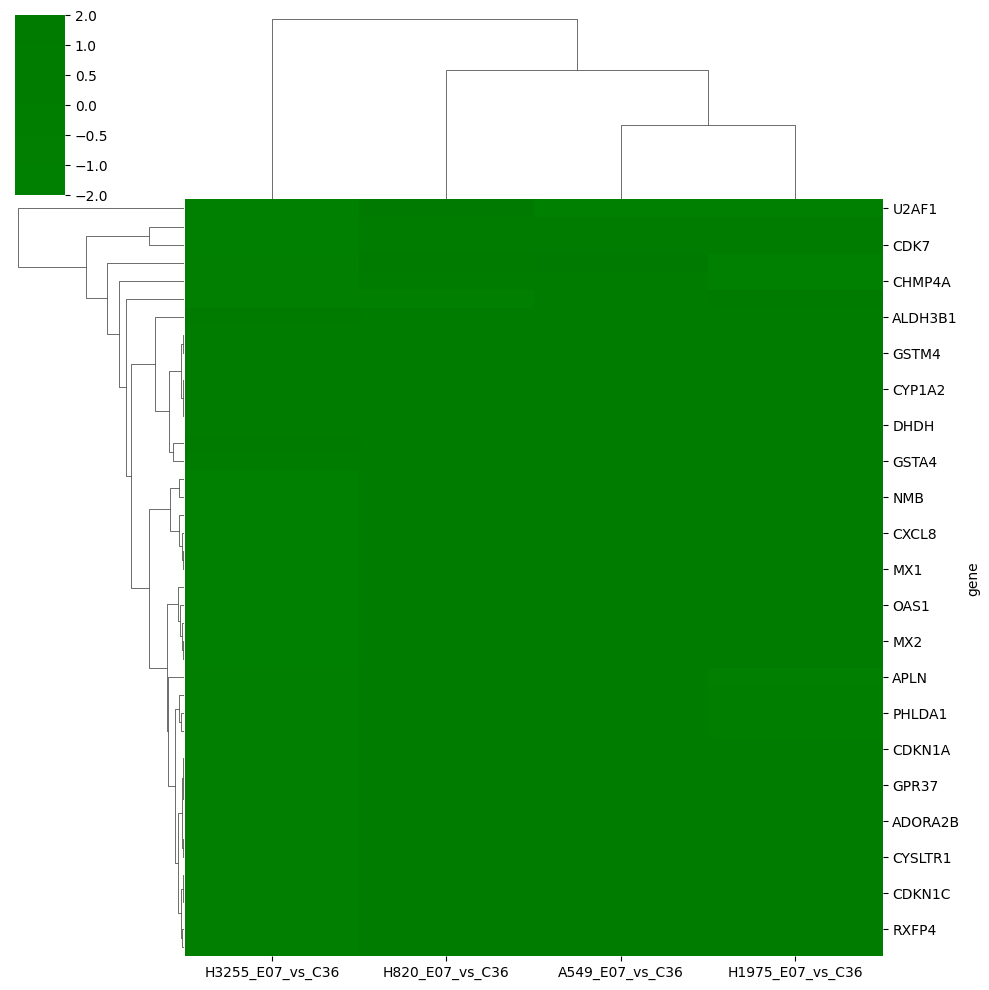

In [67]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from scipy.cluster.hierarchy import linkage, dendrogram

# Generate random data for demonstration
# Replace this with your actual data
# genes = [f'Gene{i}' for i in range(100)]
# samples = [f'Sample{i}' for i in range(10)]
# data = np.random.randn(100, 10)
# log2_fold_changes = np.random.randn(100)
# p_values = np.random.uniform(0, 0.05, 100)
# cmap = LinearSegmentedColormap.from_list('custom_red_green', ['green', 'black', 'red'], N=256)
norm = [-0.5,0,0, 0.5]
# # Creating a DataFrame for the volcano plot
# volcano_df = pd.DataFrame({
#     'gene': genes,
#     'log2FoldChange': log2_fold_changes,
#     'pValue': p_values
# })

# # Volcano Plot
# volcano_df['-log10(p-value)'] = -np.log10(volcano_df['pValue'])
# plt.figure(figsize=(10, 5))
# ax = sns.scatterplot(data=volcano_df, x='log2FoldChange', y='-log10(p-value)', hue='pValue', palette=cmap)
# ax.set_title('Volcano Plot')
# plt.axhline(y=-np.log10(0.05), color='grey', linestyle='--')
# plt.axvline(x=1, color='grey', linestyle='--')
# plt.axvline(x=-1, color='grey', linestyle='--')
# plt.show()
genes_to_filter = ['AREG', 'EREG', 'EPGN','HBEGF']
# Heatmap with hierarchical clustering
# Create a DataFrame for the heatmap
heatmap_df = pd.read_csv("/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/10_DistanceMatrix/All_DEGs_v2.csv")
heatmap_df.replace(np.nan, 0, inplace=True)
heatmap_df = heatmap_df[heatmap_df['gene'].isin(cell_cycle_genes)]
heatmap_df = heatmap_df.set_index('gene')
variances = heatmap_df.var(axis=1)
std_devs = heatmap_df.std(axis=1)
high_var_threshold = variances.quantile(0.75)
highly_variable_genes_var = variances[variances > high_var_threshold].index.tolist()

# or using standard deviation
high_std_threshold = std_devs.quantile(0.75)
highly_variable_genes_std = std_devs[std_devs > high_std_threshold].index.tolist()
highly_variable_genes_std = std_devs.index.tolist()

top_500_genes = variances.nlargest(500).index

df_top_500 = heatmap_df.loc[top_500_genes]

# df_top_500 = heatmap_df
# df_top_500 = df_top_500.set_index('gene')

df_top_500.columns = ['A549_E07_vs_C36',
       'H1975_E07_vs_Veh',
       'H3255_C36_vs_Veh',
       'H1975_E07_vs_C36',
       'H3255_E07_vs_Veh',
       'H1975_C36_vs_Veh',
       'H3255_E07_vs_C36',
       'A549_C36_vs_Veh',
       'A549_E07_vs_Veh',
       'H820_C36_vs_Veh',
       'H820_E07_vs_C36',
       'H820_E07_vs_Veh']

df_top_500 = df_top_500[[
       'H820_E07_vs_C36',
       'A549_E07_vs_C36',
       'H1975_E07_vs_C36',
       'H3255_E07_vs_C36']][:200]

# Perform hierarchical clustering
gene_linkage = linkage(df_top_500, method='average')
sample_linkage = linkage(df_top_500.T, method='average')

sns.clustermap(df_top_500, row_linkage=gene_linkage, col_linkage=sample_linkage, cmap=cmap, norm=my_norm
)
# plt.savefig(output_dir+'gene_heatmap.png', dpi=500, bbox_inches='tight')

plt.show()


In [16]:
heatmap_df.columns

Index(['A549_E07_vs_A549_C362FC_greaterthan_(0.5)',
       'H1975_E07_vs_H1975_Veh2FC_greaterthan_(0.5)',
       'H3255_C36_vs_H3255_Veh2FC_greaterthan_(0.5)',
       'H1975_E07_vs_H1975_C362FC_greaterthan_(0.5)',
       'H3255_E07_vs_H3255_Veh2FC_greaterthan_(0.5)',
       'H1975_C36_vs_H1975_Veh2FC_greaterthan_(0.5)',
       'H3255_E07_vs_H3255_C362FC_greaterthan_(0.5)',
       'A549_C36_vs_A549_Veh2FC_greaterthan_(0.5)',
       'A549_E07_vs_A549_Veh2FC_greaterthan_(0.5)',
       'H820_C36_vs_H820_Veh2FC_greaterthan_(0.5)',
       'H820_E07_vs_H820_C362FC_greaterthan_(0.5)',
       'H820_E07_vs_H820_Veh2FC_greaterthan_(0.5)'],
      dtype='object')

In [6]:
heatmap_df = pd.read_csv("/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/10_DistanceMatrix/All_DEGs_v2.csv")
heatmap_df

,gene,A549_E07_vs_A549_C362FC_greaterthan_(0.5),H1975_E07_vs_H1975_Veh2FC_greaterthan_(0.5),H3255_C36_vs_H3255_Veh2FC_greaterthan_(0.5),H1975_E07_vs_H1975_C362FC_greaterthan_(0.5),H3255_E07_vs_H3255_Veh2FC_greaterthan_(0.5),H1975_C36_vs_H1975_Veh2FC_greaterthan_(0.5),H3255_E07_vs_H3255_C362FC_greaterthan_(0.5),A549_C36_vs_A549_Veh2FC_greaterthan_(0.5),A549_E07_vs_A549_Veh2FC_greaterthan_(0.5),H820_C36_vs_H820_Veh2FC_greaterthan_(0.5),H820_E07_vs_H820_C362FC_greaterthan_(0.5),H820_E07_vs_H820_Veh2FC_greaterthan_(0.5)
0,ABR-3,0.496955,NaN,NaN,-0.509694,-1.56045,NaN,-1.310350,NaN,NaN,NaN,NaN,NaN
1,ACACA,0.826102,NaN,NaN,0.728985,NaN,-0.625746,NaN,0.766238,1.59132,0.596987,-0.564972,NaN
2,ACACA-2,0.522437,NaN,NaN,NaN,NaN,NaN,0.499677,NaN,NaN,NaN,NaN,NaN
3,ACTG1-2,-1.227110,5.50893,NaN,2.914770,1.19978,2.598030,2.510680,1.758330,NaN,-1.548470,2.677260,1.130110
4,ACTN4-2,1.081750,NaN,NaN,-0.639110,-1.18592,0.550177,-1.199420,NaN,0.82967,-1.066870,-0.353275,-1.419230
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4721,WASF4P,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.914605
4722,WASHC1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.672967
4723,ZNF354B,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.267746
4724,ZNF57,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.436172


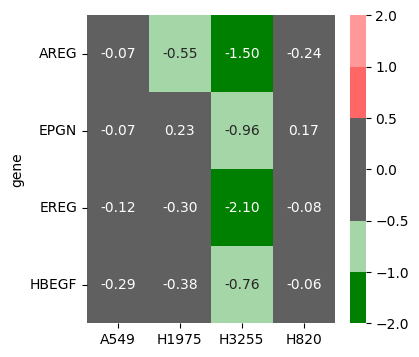

In [61]:
#ligand heatmap
import pandas as pd
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm, ListedColormap


my_colors = ['green', '#A5D6A7','#606060','#606060' ,'#FF6666','#FF9999']
cmap = ListedColormap(my_colors)
bounds = [-2,-1,-0.5, 0, 0.5,1,2]
my_norm = BoundaryNorm(bounds, ncolors=len(my_colors))
path = "/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/gene_pathway/ligands.csv"


data = pd.read_csv(path)

# data = heatmap_df
data = data.set_index('gene')

# Set the gene column as the index to use it as row labels

# Set up the matplotlib figure
plt.figure(figsize=(4, 4))

# Draw the heatmap with the numeric values in each cell
heatmap = sns.heatmap(data, annot=True, fmt=".2f", cmap=cmap, norm=my_norm)

# Add a title to the heatmap
# plt.title('Heatmap of Gene Expression', fontsize=20)

# Rotate the y-axis labels for better readability if necessary
plt.yticks(rotation=0)
plt.savefig(output_dir+'ligand_heatmap.png', dpi=200, bbox_inches='tight')

# Show the heatmap
plt.show()




         gene  A549_E07_vs_A549_C362FC_greaterthan_(0.5)  \
75     GTF2H1                                   2.132000   
152     PSME1                                   0.765308   
208     U2AF1                                  -3.598080   
257   ALDH3B1                                   0.000000   
277      APLN                                   0.000000   
582     GSTA4                                   0.000000   
996      RRM2                                   0.000000   
1248   CDKN1C                                   0.000000   
1250   CHMP4A                                   0.000000   
1282    IFIT1                                   0.000000   
1285    ISG15                                   0.000000   
1317      MX1                                   0.000000   
1318      MX2                                   0.000000   
1320    MZT2B                                   0.000000   
1332     OAS1                                   0.000000   
1333     OASL                           

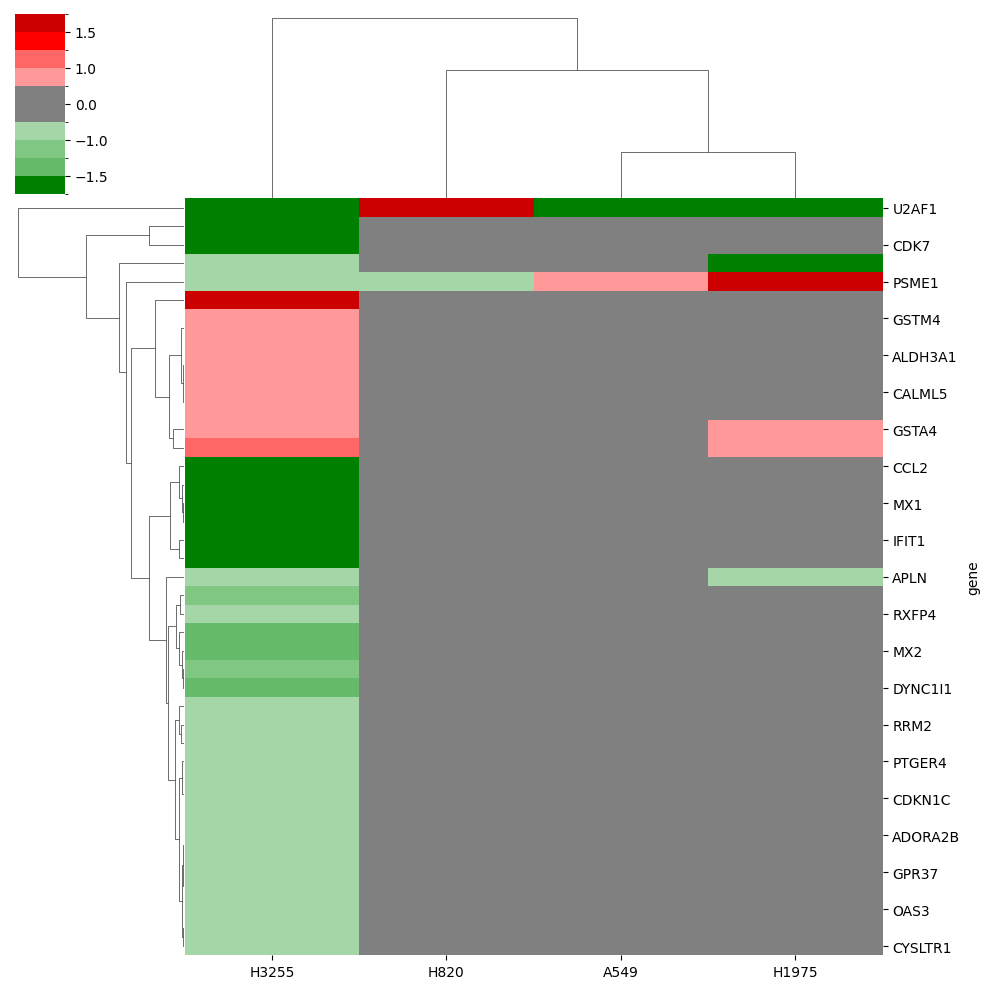

In [47]:
import pandas as pd
import numpy as np
import seaborn as sns
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
from scipy.cluster.hierarchy import linkage, dendrogram

cell_cycle_genes = pd.read_excel("/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/gene_pathway/H3255_pathways.xlsx", sheet_name='g2p')['gene_'].unique()

genes_to_filter = cell_cycle_genes
# genes_to_filter = li_immune_gens
# Heatmap with hierarchical clustering
# Create a DataFrame for the heatmap
heatmap_df = pd.read_csv("/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/10_DistanceMatrix/All_DEGs_v2.csv")
heatmap_df = heatmap_df.replace(np.nan, 0)
heatmap_df = heatmap_df[heatmap_df['H3255_E07_vs_H3255_C362FC_greaterthan_(0.5)'] !=0]
# heatmap_df = heatmap_df.sort_values('H3255_E07_vs_H3255_C362FC_greaterthan_(0.5)')

heatmap_df = heatmap_df[heatmap_df['gene'].isin(genes_to_filter)]
print(heatmap_df)

my_colors = ['green', '#66BB6A','#81C784','#A5D6A7',
             'grey','grey' ,
             '#FF9999','#FF6666','#FF0000','#CC0000']
cmap = ListedColormap(my_colors)
bounds = [-2,-1.5,-1.25,-1,-0.5, 0, 0.5,1,1.25,1.5,2]
my_norm = BoundaryNorm(bounds, ncolors=len(my_colors))

heatmap_df = heatmap_df[['gene','A549_E07_vs_A549_C362FC_greaterthan_(0.5)',
       'H1975_E07_vs_H1975_C362FC_greaterthan_(0.5)',
       'H3255_E07_vs_H3255_C362FC_greaterthan_(0.5)',
       'H820_E07_vs_H820_C362FC_greaterthan_(0.5)']][1:100]
heatmap_df.columns = ['gene','A549', 'H1975','H3255','H820']
heatmap_df = heatmap_df.set_index('gene')
heatmap_df = heatmap_df.round(2)
# heatmap_df.sort_values('H3255', ascending=True, inplace=True)
# # Perform hierarchical clustering
gene_linkage = linkage(heatmap_df, method='average')
sample_linkage = linkage(heatmap_df.T, method='average')
# cmap = LinearSegmentedColormap.from_list('custom_red_green', ['green', 'black', 'red'], N=256)

sns.clustermap(heatmap_df, row_linkage=gene_linkage,  col_linkage=sample_linkage, cmap=cmap, norm = my_norm
)
# plt.savefig(output_dir+'cellcycle_genes.png', dpi=500, bbox_inches='tight')

plt.show()



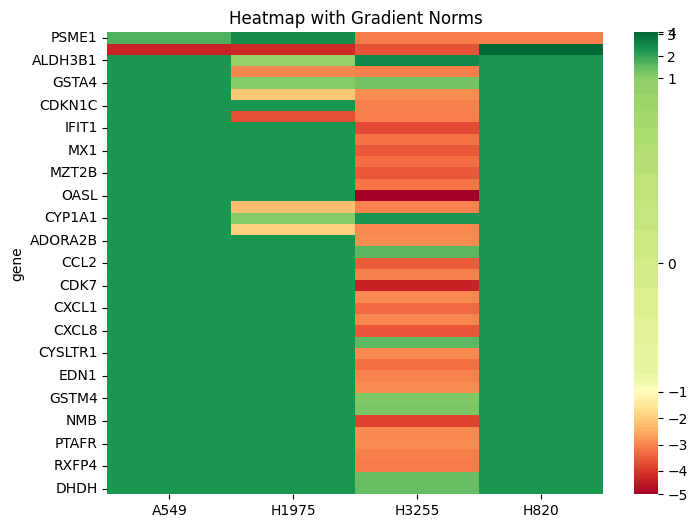

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
import pandas as pd

# Example DataFrame
np.random.seed(0)
data = np.random.randn(10, 10)
df = heatmap_df

# Define a continuous colormap
cmap = plt.cm.RdYlGn  # A green to red colormap

# Define custom normalization
class CustomNorm(mcolors.Normalize):
    def __init__(self, vmin=None, vmax=None, clip=False):
        mcolors.Normalize.__init__(self, vmin, vmax, clip)

    def __call__(self, value, clip=None):
        # Define thresholds
        x0, x1, x2 = -0.5, 0.5, 1.0  # Adjust x2 if needed
        # Map the value ranges to [0, 1] for the colormap
        return np.ma.masked_array(np.interp(value, [self.vmin, x0, x1, x2, self.vmax], [0, 0.25, 0.75, 0.9, 1]))

# Apply custom normalization
norm = CustomNorm(vmin=df.min().min(), vmax=df.max().max())

# Plot the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df, cmap=cmap, norm=norm)
plt.title("Heatmap with Gradient Norms")
plt.show()


In [26]:
heatmap_df.round(2)

,A549,H1975,H3255,H820
gene,,,,
OASL,1.00,1.00,-4.89,1.00
CDK7,1.00,1.00,-3.60,1.00
EEF1D,1.02,1.00,-2.96,1.19
CNOT10,1.00,1.00,-2.87,-1.84
NMB,1.00,1.00,-2.60,1.00
...,...,...,...,...
PEX5,-1.45,1.00,2.23,0.70
PAEP,1.00,1.00,2.23,1.00
PNP,2.19,-0.72,2.30,1.13


In [58]:
import pandas as pd
filepath = "/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/dataforplots/H3255_E07_vs_H3255_C36_immune.csv"

df = pd.read_csv(filepath)
# df['pathway'] = df['pathy'].str.lower()
# df['pathway'] = df['pathway'].str.replace("_"," ")
df = df.sort_values("intersection_size")


df.head(2)


,Unnamed: 0,source,native,name,p_value,query_size,intersection_size,query,parents,intersections
3,232,REAC,REAC:R-HSA-75205,Dissolution of Fibrin Clot,0.003519,448,6,query_1,['REAC:R-HSA-109582'],"['PLAT', 'PLAU', 'PLAUR', 'SERPINB6', 'SERPINB..."
8,350,KEGG,KEGG:00410,beta-Alanine metabolism,0.024751,341,7,query_1,['KEGG:00000'],"['ABAT', 'ACADS', 'ALDH2', 'ALDH3A1', 'ALDH3B1..."


In [28]:
import plotly.express as px
color_continuous_scale ='Rdbu',
fig = px.bar(df, x='intersection_size', y='name', orientation='h',
             labels={'intersection_size':'Gene Count','p_value':'p-value'},
            #  hover_data=[' p_value','description','intersections'], 
             color='p_value', color_continuous_scale=["red", 
                                         "blue"], range_color=[0, 0.05, 0.01])
# fig.update_layout(xaxis_range=[0,300],margin=dict(l=30, r=20, t=20, b=20),)
fig.update_layout(yaxis = dict(
tickfont = dict(size=8)),
plot_bgcolor = 'white',
width=1000, height=800)
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey'
)
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey',
    tickfont=dict(size=13)
)


fig.update_layout(xaxis_range=[-1,1])
fig.show()

NameError: name 'df' is not defined

In [63]:
import plotly.io as pio
pio.write_image(fig, 'H3255_Immune.pdf', width=1000, height=800)

In [6]:
# GO Terms
import plotly.express as px
color_continuous_scale ='Rdbu',
fig = px.bar(df, x='intersection_sizesize', y='pathway', orientation='h',
             labels={'size':'Gene Count','name':'GO Term'},
            #  hover_data=[' p_value','description','intersections'], 
             color='padj', color_continuous_scale=["red", 
                                         "blue", "purple"])
fig.update_layout(xaxis_range=[0,300],margin=dict(l=30, r=20, t=20, b=20),)
fig.update_layout(yaxis = dict(
tickfont = dict(size=8)),
plot_bgcolor = 'white')
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey'
    
)
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey'
)



fig.show()

ValueError: Value of 'x' is not the name of a column in 'data_frame'. Expected one of ['Unnamed: 0', 'source', 'native', 'name', 'p_value', 'term_size', 'query_size', 'intersection_size', 'query', 'parents', 'intersections'] but received: size

In [6]:
heatmap_df.columns = [['A549_E07_vs_A549_C362FC_greaterthan_(0.5)',
       'H1975_E07_vs_H1975_C362FC_greaterthan_(0.5)',
       'H3255_E07_vs_H3255_C362FC_greaterthan_(0.5)',
       'H820_E07_vs_H820_C362FC_greaterthan_(0.5)']]


ValueError: Length mismatch: Expected axis has 12 elements, new values have 4 elements

In [8]:
# Unique genes in a subset.

import pandas as pd
import numpy as np
heatmap_df = pd.read_csv("/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/10_DistanceMatrix/All_DEGs_v2.csv", index_col='gene')
heatmap_df.replace(np.nan, 0, inplace=True)
df = heatmap_df[['A549_E07_vs_A549_C362FC_greaterthan_(0.5)',
       'H1975_E07_vs_H1975_C362FC_greaterthan_(0.5)',
       'H3255_E07_vs_H3255_C362FC_greaterthan_(0.5)',
       'H820_E07_vs_H820_C362FC_greaterthan_(0.5)']]
df.columns =  ['A549', 'H1975', 'H3255', 'H820']
non_zero_h1975 = df[df['H1975'] != 0]

# Filter genes with zero values in other columns
zero_other_columns = df[(df['A549'] == 0) & (df['H820'] == 0) & (df['H3255'] == 0)]

# Find unique genes in H1975 compared to the other columns by intersecting the above two filters
unique_genes_h1975 = non_zero_h1975.index.intersection(zero_other_columns.index)

# Convert the Index object to a list if you need to use it as a list
unique_genes_list = unique_genes_h1975.tolist()

# Printing or using the unique genes
print("Unique genes in H1975 compared to A549, H820, H3255:")
print(unique_genes_list)
len(unique_genes_list)


Unique genes in H1975 compared to A549, H820, H3255:
['ABHD4', 'ACE', 'ACKR3', 'ACOX2', 'ACP5', 'ACSF2', 'ADA', 'ADGRV1', 'AEN', 'AGT', 'AHNAK2', 'AKR1B10', 'AKR1C1', 'AKR1C3', 'AMOTL1', 'AMZ2P1', 'ANGPTL4', 'ANKLE1', 'APCDD1L', 'APOBR', 'AQP1', 'AQP11', 'ARHGAP22', 'ARHGAP30', 'ARHGAP31', 'ASF1B', 'ATP1A2', 'C11orf24', 'C1S', 'C1orf21', 'C3', 'C4B', 'C5AR1', 'CA9', 'CACNA1H', 'CARF', 'CCN5', 'CCNF', 'CD177', 'CDC20P1', 'CDC25A', 'CDC6', 'CDC7', 'CDCA7L', 'CDH11', 'CDH5', 'CDKN3', 'CHI3L2', 'CHRNB4', 'CLDN2', 'COL12A1', 'COL13A1', 'COL1A1', 'COL1A2', 'COL26A1', 'CPE', 'CREB3L3', 'CREB5', 'CRIP1', 'CSDC2', 'CSPG4', 'CT45A2', 'CYP27A1', 'CYP4F12', 'DAXX-5', 'DCAF11', 'DCAF15-2', 'DCP1B', 'DDO', 'DGKG', 'DIO2', 'DKC1', 'DNAJC27-AS1', 'DNMBP', 'DTL', 'DUSP2', 'DUSP7', 'E2F1', 'EBNA1BP2', 'EFNB2', 'EMP1', 'ERCC6L', 'EXO1', 'FAM111B', 'FAT2', 'FBXO2', 'FEN1', 'FPR1', 'FYB1', 'G0S2', 'GABRB3', 'GASK1B', 'GBP2', 'GLP2R', 'GPATCH4-2', 'GPR132', 'GPR173', 'GRIN2A', 'GTF2IP1', 'H2AC11', 'H2AC13',

630

In [12]:
#get genes to create Heatmap # Cell cycle related genes
import ast
df_genes = pd.read_csv("/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/dataforplots/H3255_E07_vs_H3255_C36_GO.csv")
df_genes['intersections'] = df_genes['intersections'].apply(ast.literal_eval)
df_genes = df_genes.explode('intersections')
cell_cycle_genes = df_genes['intersections'].unique()
len(cell_cycle_genes)

419

In [51]:
df_immune_genes = pd.read_csv("/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/dataforplots/H3255_E07_vs_H3255_C36_immune.csv")
immune_pathways = [ 
       'Interferon alpha/beta signaling']
df_immune_genes = df_immune_genes[df_immune_genes['name'].isin(immune_pathways)]
df_immune_genes['intersections'] = df_immune_genes['intersections'].apply(ast.literal_eval)
df_immune_genes = df_immune_genes.explode('intersections')
li_immune_gens = df_immune_genes['intersections'].unique()
len(li_immune_gens)

13

In [64]:
df = pd.read_csv("/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/PPI/all_degs.csv", sep="\t")
df = df[df['condition'].isin(['E07_vs_C36'])]
df[df['gene'].isin(['AREG', 'EREG', 'EPGN','HBEGF'])].pivot(index='gene',values='log2(fold_change)', columns='cell_line').to_csv(output_dir+"ligands.csv")

In [63]:
df_cuff = pd.read_csv("/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/8_cuffdiff_result/Cuffdiff_new/A549_E07_vs_A549_C36/gene_exp.diff", sep="\t")
df_cuff[df_cuff['gene'] == 'EPGN']

,test_id,gene_id,gene,locus,sample_1,sample_2,status,value_1,value_2,log2(fold_change),test_stat,p_value,q_value,significant
8846,gene-EPGN,gene-EPGN,EPGN,NC_000004.12:74114559-74388749,q1,q2,NOTEST,0.0,0.023098,inf,0.0,1.0,1.0,no


In [16]:
#CC Terms for each cell
import plotly.express as px
import pandas as pd
file_path = "/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/dataforplots/H1975_E07_vs_C36_GO.xlsx"
df = pd.read_excel(file_path)

color_continuous_scale ='Rdbu',
fig = px.bar(df, x='intersection_size', y='name', orientation='h',
             labels={'intersection_size':'Gene Count','name':'GO:CC Terms'},
            #  hover_data=[' p_value','description','intersections'], 
             color='p_value', color_continuous_scale=["red", 
                                         "blue", "purple"])
# fig.update_layout(xaxis_range=[0,300],margin=dict(l=30, r=20, t=20, b=20),)
fig.update_layout(yaxis = dict(
tickfont = dict(size=8)),
plot_bgcolor = 'white')
fig.update_xaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey'
)
fig.update_yaxes(
    mirror=True,
    ticks='outside',
    showline=True,
    linecolor='black',
    gridcolor='lightgrey'
)



fig.show()

In [31]:
import plotly.io as pio
pio.write_image(fig, 'H1975_GO.pdf', width=800, height=500)

In [1]:
#checking for gene ration - impress
import pandas as pd
df = pd.read_csv("/scratch/sah2p/datasets/hg38/annotation/Homo_sapiens.gene_info.txt", sep='\t')
df_summary = df['type_of_gene'].value_counts().reset_index()

In [2]:
df_summary['total'] = df.shape[0]
df_summary['percent'] = df_summary['count']/df_summary['total']*100
df_summary

,type_of_gene,count,total,percent
0,biological-region,128259,193477,66.291601
1,ncRNA,22122,193477,11.433917
2,protein-coding,20643,193477,10.669485
3,pseudo,17454,193477,9.021227
4,unknown,1290,193477,0.666746
5,snoRNA,1201,193477,0.620746
6,other,846,193477,0.437261
7,rRNA,785,193477,0.405733
8,tRNA,701,193477,0.362317
9,snRNA,172,193477,0.088899


In [5]:
15/66*100

22.727272727272727

In [6]:
49/66


0.7424242424242424

In [7]:
df[df['type_of_gene'] == 'ncRNA']

,#tax_id,GeneID,Symbol,LocusTag,Synonyms,dbXrefs,chromosome,map_location,description,type_of_gene,Symbol_from_nomenclature_authority,Full_name_from_nomenclature_authority,Nomenclature_status,Other_designations,Modification_date,Feature_type
503,9606,618,BCYRN1,-,BC200|BC200a|LINC00004|NCRNA00004,MIM:606089|HGNC:HGNC:1022|Ensembl:ENSG00000236...,2,2p21,brain cytoplasmic RNA 1,ncRNA,BCYRN1,brain cytoplasmic RNA 1,O,BC200-alpha|brain cytoplasmic RNA 1 (analog of...,20231010,-
579,9606,711,ERC2-IT1,-,C1orf1|C3orf51|Po42,HGNC:HGNC:1229|Ensembl:ENSG00000281708|Allianc...,3,3p14.3,ERC2 intronic transcript 1,ncRNA,ERC2-IT1,ERC2 intronic transcript 1,O,ERC2 intronic transcript 1 (non-protein coding),20231010,-
610,9606,750,GAS8-AS1,-,C16orf3,MIM:605179|HGNC:HGNC:1197|Ensembl:ENSG00000221...,16,16q24.3,GAS8 antisense RNA 1,ncRNA,GAS8-AS1,GAS8 antisense RNA 1,O,uncharacterized protein C16orf3,20231010,-
698,9606,856,CATR1,-,-,MIM:600676|HGNC:HGNC:1525,7,7q32,CATR tumorigenicity conversion 1,ncRNA,CATR1,CATR tumorigenicity conversion 1,O,CATR tumorigenic conversion 1,20230907,-
2949,9606,3653,IPW,-,NCRNA00002,MIM:601491|HGNC:HGNC:6109|AllianceGenome:HGNC:...,15,15q11.2,imprinted in Prader-Willi syndrome,ncRNA,IPW,imprinted in Prader-Willi syndrome,O,imprinted in Prader-Willi syndrome (non-protei...,20231010,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
193392,9606,132503825,TGFBRAP1-AS1,-,-,HGNC:HGNC:56908,2,2q12.2,TGFBRAP1 antisense RNA 1,ncRNA,TGFBRAP1-AS1,TGFBRAP1 antisense RNA 1,O,-,20231007,-
193393,9606,132532400,GABRA6-AS1,-,ARBAG,HGNC:HGNC:40248,5,5q34,GABRA6 antisense RNA 1,ncRNA,GABRA6-AS1,GABRA6 antisense RNA 1,O,-,20231111,-
193400,9606,132565735,YY1-DT,-,-,HGNC:HGNC:56936,14,14q32.2,YY1 divergent transcript,ncRNA,YY1-DT,YY1 divergent transcript,O,RP11-638I2.4,20231105,-
193401,9606,132565736,LINC03121,-,-,HGNC:HGNC:56937,1,1q31.1,long intergenic non-protein coding RNA 3121,ncRNA,LINC03121,long intergenic non-protein coding RNA 3121,O,Lnc-PAL2G4A-4,20231016,-


In [3]:
import pandas as pd
df_kegg = pd.read_excel("/scratch/sah2p/projects/RNASeqPipeline/output_dirkegg_gene_mapping.xlsx")
df_kegg.columns

Index(['X', 'gene', 'p_value', 'q_value', 'significant', 'log2.fold_change.',
       'condition', 'cell_line', 'KEGG_id'],
      dtype='object')

In [ ]:
df_kegg.shape

(797040, 9)

In [5]:
df_results = pd.merge(df_kegg, df, left_on='gene', right_on='Symbol', how='left')


In [6]:
test = df_results[df_results['KEGG_id'].isna()][['gene','type_of_gene']].drop_duplicates()
    
# test[test['type_of_gene'] == 'protein-coding']
test

,gene,type_of_gene
13,AAAS-2,NaN
18,AADACL2-2,NaN
20,AADACL2-AS1-2,NaN
36,AARSD1P1,pseudo
42,AATF-2,NaN
...,...,...
66557,rna-NR_162123.1,NaN
66558,rna-NR_162124.1,NaN
66559,rna-NR_162125.1,NaN
66560,rna-NR_162126.1,NaN


#### DotPlot for NES

In [14]:
import pandas as pd
df_H3255 = pd.read_csv("/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/dataforplots/H3255_E07_vs_C36_Reactome.csv")
df_H1975 = pd.read_csv("/scratch/sah2p/datasets/2023_11_04_BurkeLab/output/dataforplots/H1975_E07_vs_C36_Reactome.csv")
df_H1975['pathway'] = df_H1975['pathway'].str.lower().str.replace("_"," ")
df_H3255['pathway'] = df_H3255['pathway'].str.lower().str.replace("_"," ")



In [64]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    y=df_H1975['pathway'], 
    x = df_H1975['NES'],
    name='H1975',
    marker=dict(
        color='gold',
        line_color='gold',
    )
))
# ,
# fig.add_trace(go.Scatter(
#     x=df_H3255['NES'], y=df_H3255['pathway'],
#     name='H3255',
#     marker=dict(
#         color='crimson',
#         line_color='crimson'
#     )
# ))

fig.update_traces(mode='markers', marker=dict(line_width=1, symbol='circle', size=16))

fig.update_layout(
    title="Pathway Enrichment Score for H3255",
    xaxis=dict(
        showgrid=True,
        showline=True,
        linecolor='black',
        tickfont_color='black',
        showticklabels=True,
        dtick=2,
        ticks='outside',
        tickcolor='black',
    ),
    margin=dict(l=140, r=40, b=50, t=80),
    legend=dict(
        font_size=10,
        yanchor='middle',
        xanchor='right',
    ),
    width=1000,
    height=600,
    paper_bgcolor='white',
    plot_bgcolor='white',
    hovermode='closest',
)
fig.update_layout(xaxis_range=[-2,0])
fig.show()


In [65]:
fig.write_image("NES_H3255.pdf")
